# Transfer learning в решении задачи классификации цветов
Датасет классификации цветов (http://www.robots.ox.ac.uk/~vgg/data/flowers/102/index.html) состоит из 102 видов цветов встречаемых в Великобритании. Для каждого класса есть от 40 до 258 примеров, чего мало для обучения с нуля:
<img src="http://bennycheung.github.io/images/deep-transfer-learning-on-small-dataset/flower_train_samples_700.jpg" style="width:50%">

In [39]:
import os

# Путь к папке с датасетом
dataset_dir = "input/flower-dataset-102"
os.makedirs(dataset_dir, exist_ok=True)

# 1. Проверяем и скачиваем архив с картинками
tgz_path = os.path.join(dataset_dir, "102flowers.tgz")
if not os.path.exists(tgz_path):
    print("Архив не найден. Начинаю скачивание...")
    !wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz -O {tgz_path}
else:
    print("Архив 102flowers.tgz уже скачан, пропускаю.")

# 2. Проверяем и скачиваем файл с метками
mat_path = os.path.join(dataset_dir, "imagelabels.mat")
if not os.path.exists(mat_path):
    print("Файл меток не найден. Начинаю скачивание...")
    !wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat -O {mat_path}
else:
    print("Файл imagelabels.mat уже скачан, пропускаю.")


Архив 102flowers.tgz уже скачан, пропускаю.
Файл imagelabels.mat уже скачан, пропускаю.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io
import tarfile
import csv
import sys
import os

In [3]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.models as M
import tensorflow.keras.layers as L
import tensorflow.keras.backend as K
import tensorflow.keras.callbacks as C
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint, EarlyStopping
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import optimizers
import efficientnet.tfkeras as efn

I0000 00:00:1778947190.128871  207291 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
from sklearn.model_selection import train_test_split

import PIL
from PIL import ImageOps, ImageFilter
#увеличим дефолтный размер графиков
from pylab import rcParams
rcParams['figure.figsize'] = 10, 5
%matplotlib inline

print(os.listdir("./input"))
print('Python       :', sys.version.split('\n')[0])
print('Numpy        :', np.__version__)
print('Tensorflow   :', tf.__version__)

['flower-dataset-102']
Python       : 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0]
Numpy        : 1.26.4
Tensorflow   : 2.21.0


In [5]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [6]:
# Проверяем что у нас работает GPU
tf.test.gpu_device_name()

''

Работаем уже с Tensorflow 2.1 но для воспроизводимости сохраним версии всех пакетов

In [7]:
!pip freeze > requirements.txt

# Setup

In [8]:
# В сетап выношу основные настройки, так удобней их перебирать в дальнейшем

EPOCHS               = 5
BATCH_SIZE           = 8 # уменьшаем batch если сеть большая, иначе не влезет в память на GPU
LR                   = 1e-3
VAL_SPLIT            = 0.2

CLASS_NUM            = 102
IMG_SIZE             = 250
IMG_CHANNELS         = 3
input_shape          = (IMG_SIZE, IMG_SIZE, IMG_CHANNELS)

DATA_PATH = './input/flower-dataset-102/'
PATH = "./working/flower/"

In [9]:
# Setting seed for reproducibility
#os.makedirs(PATH,exist_ok=False)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
PYTHONHASHSEED = 0

# Data

In [10]:
# прочитаем все названия файлов прям из архива и таргеты к ним
def get_all_filenames(tar_fn):
    with tarfile.open(tar_fn) as f:
        return [m.name for m in f.getmembers() if m.isfile()]

df = pd.DataFrame()
df['Id'] = sorted(get_all_filenames(DATA_PATH+"102flowers.tgz"))
df['Category'] = scipy.io.loadmat(DATA_PATH+'imagelabels.mat')['labels'][0] - 1  # классы (0, 1, 2, ...)
df['Category'] = df['Category'].astype(str)

In [11]:
df.head(5)

,Id,Category
0,jpg/image_00001.jpg,76
1,jpg/image_00002.jpg,76
2,jpg/image_00003.jpg,76
3,jpg/image_00004.jpg,76
4,jpg/image_00005.jpg,76


In [12]:
df['Category'].value_counts()

Category
50    258
76    251
45    196
72    194
88    184
     ... 
6      40
44     40
33     40
0      40
26     40
Name: count, Length: 102, dtype: int64

In [13]:
df['Category'].nunique()

102

In [40]:
import os
import tarfile

# Путь к папке, куда распаковываются картинки
extracted_images_dir = os.path.join(PATH, 'jpg')

# Проверяем, существует ли уже папка с распакованными картинками
if not os.path.exists(extracted_images_dir):
    print('Распаковываем картинки...')
    opened_tar = tarfile.open(DATA_PATH + "102flowers.tgz")
    opened_tar.extractall(PATH)
    opened_tar.close()  # Не забываем закрыть файл после распаковки
    print('Распаковка успешно завершена!')
else:
    print('Картинки уже были распакованы ранее, пропускаю этот шаг.')

# Выводим первые 5 файлов для проверки
print("Примеры файлов в папке:", os.listdir(extracted_images_dir)[:5])


Картинки уже были распакованы ранее, пропускаю этот шаг.
Примеры файлов в папке: ['image_08054.jpg', 'image_06567.jpg', 'image_01443.jpg', 'image_05492.jpg', 'image_00465.jpg']


Пример картинок (random sample)


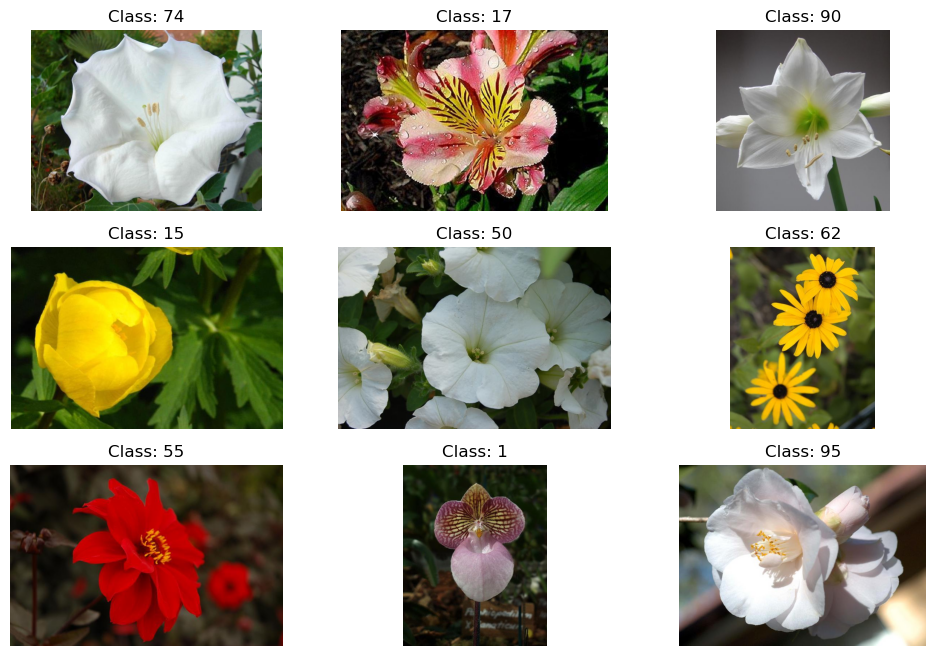

In [15]:
print('Пример картинок (random sample)')
plt.figure(figsize=(12,8))

random_image = df.sample(n=9)
random_image_paths = random_image['Id'].values
random_image_cat = random_image['Category'].values

for index, path in enumerate(random_image_paths):
    im = PIL.Image.open(PATH+path)
    plt.subplot(3,3, index+1)
    plt.imshow(im)
    plt.title('Class: '+str(random_image_cat[index]))
    plt.axis('off')
plt.show()

Пример картинок (random sample)


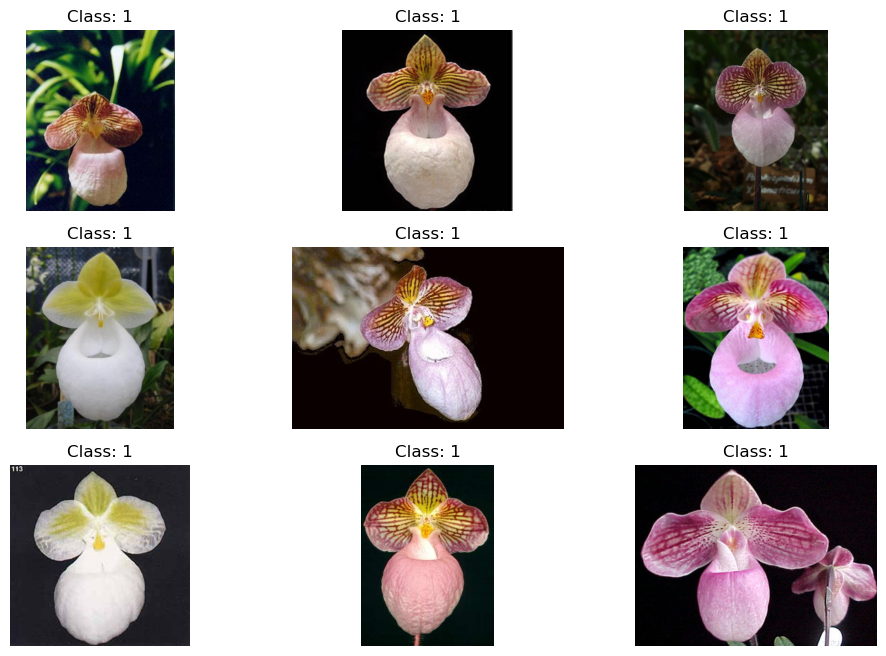

In [16]:
# убедимся что метки классов подгрузились верно
print('Пример картинок (random sample)')
plt.figure(figsize=(12,8))

random_image = df[df['Category']=='1'].sample(n=9)
random_image_paths = random_image['Id'].values
random_image_cat = random_image['Category'].values

for index, path in enumerate(random_image_paths):
    im = PIL.Image.open(PATH+path)
    plt.subplot(3,3, index+1)
    plt.imshow(im)
    plt.title('Class: '+str(random_image_cat[index]))
    plt.axis('off')
plt.show()

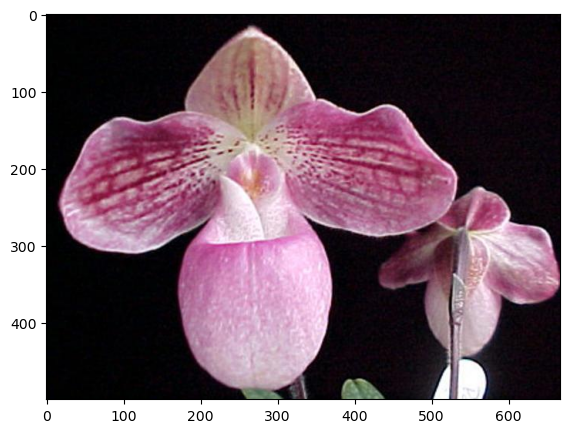

(667, 500)

In [17]:
# как видим изображения имеют разный размер
image = PIL.Image.open(PATH+path)
imgplot = plt.imshow(image)
plt.show()
image.size

 ## Stratify Split

In [18]:
# трейн / тест
train_files, test_files, train_labels, test_labels = \
    train_test_split(df['Id'], df['Category'], test_size=0.2, random_state=42, stratify=df['Category'])

train_files = pd.DataFrame(train_files)
test_files = pd.DataFrame(test_files)
train_files['Category'] = train_labels
test_files['Category'] = test_labels

train_files.shape, test_files.shape

((6551, 2), (1638, 2))

In [19]:
train_files.head(5)

,Id,Category
2361,jpg/image_02362.jpg,42
512,jpg/image_00513.jpg,87
5969,jpg/image_05970.jpg,68
6251,jpg/image_06252.jpg,60
516,jpg/image_00517.jpg,87


In [20]:
train_files['Category'].value_counts()

Category
50    206
76    201
45    157
72    155
88    147
     ... 
0      32
6      32
33     32
2      32
26     32
Name: count, Length: 102, dtype: int64

In [21]:
test_files['Category'].value_counts()

Category
50    52
76    50
72    39
45    39
88    37
      ..
78     8
0      8
20     8
24     8
66     8
Name: count, Length: 102, dtype: int64

### Data augmentation

In [22]:
# Аугментация данных очень важна когда у нас не большой датасет (как в нашем случае)

# Убрали rescale, оставив только аугментацию данных
train_datagen = ImageDataGenerator(
    rotation_range=50,
    shear_range=0.2,
    zoom_range=[0.75, 1.25],
    brightness_range=[0.5, 1.5],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Для теста теперь создаем пустой генератор без изменений
test_datagen = ImageDataGenerator() 


### datagen

In [41]:
# "Заворачиваем" наши данные в generator

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_files,
    directory=PATH,
    x_col="Id",
    y_col="Category",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=RANDOM_SEED,)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_files,
    directory=PATH,
    x_col="Id",
    y_col="Category",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=RANDOM_SEED,)

Found 6551 validated image filenames belonging to 102 classes.
Found 1638 validated image filenames belonging to 102 classes.


Пример картинок из train_generator


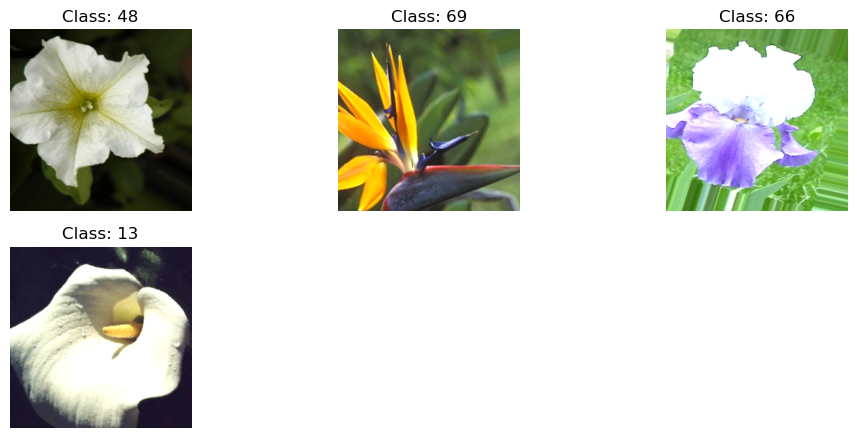

In [44]:
from skimage import io

def imshow(image_RGB):
  io.imshow(image_RGB)
  io.show()

x,y = next(train_generator)
print('Пример картинок из train_generator')
plt.figure(figsize=(12,8))

for i in range(0,4):
    image = x[i]
    plt.subplot(3,3, i+1)

    # Добавьте .astype('uint8'), чтобы matplotlib правильно понял диапазон 0..255
    plt.imshow(image.astype('uint8'))
    
    # По желанию можно раскомментировать эти строки для красоты:
    plt.title('Class: ' + str(y[i].argmax())) # argmax покажет номер класса вместо вектора
    plt.axis('off')    
    
plt.show()

Пример картинок из test_generator


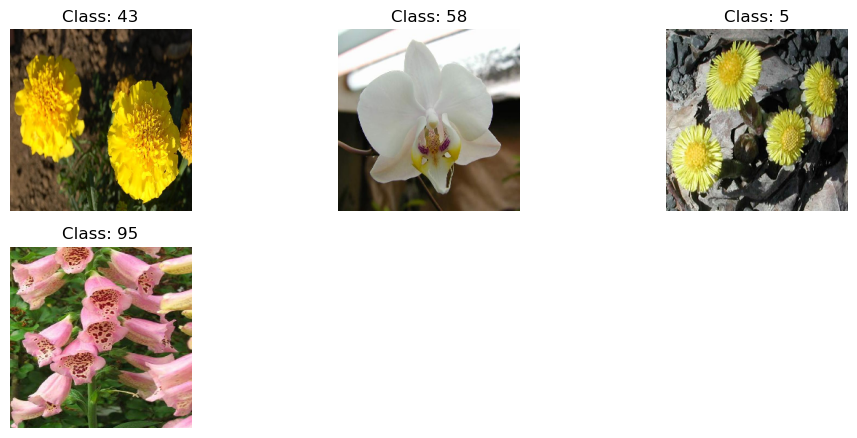

In [45]:
x,y = next(test_generator)
print('Пример картинок из test_generator')
plt.figure(figsize=(12,8))

for i in range(0,4):
    image = x[i]
    plt.subplot(3,3, i+1)
    # Добавьте .astype('uint8'), чтобы matplotlib правильно понял диапазон 0..255
    plt.imshow(image.astype('uint8'))
    
    # По желанию можно раскомментировать эти строки для красоты:
    plt.title('Class: ' + str(y[i].argmax())) # argmax покажет номер класса вместо вектора
    plt.axis('off')    
plt.show()

# Model

In [46]:
input_shape

(250, 250, 3)

In [47]:
import tensorflow as tf

# Прямой импорт из актуального Keras
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet', 
    include_top=False, 
    input_shape=input_shape
)


In [48]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 250, 250,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 250, 250,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 250, 250,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 250, 250,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 251, 251,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 125, 125,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 125, 125,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 125, 125,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 125, 125,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 125, 125,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 125, 125,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 125, 125,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 125, 125,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [49]:
# first: train only the top layers (which were randomly initialized)
base_model.trainable = False

In [50]:
model=M.Sequential()
model.add(base_model)
model.add(L.GlobalAveragePooling2D(),)
model.add(L.Dense(CLASS_NUM, activation='softmax'))

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,180,233 (15.95 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [52]:
# сколько слоев
print(len(model.layers))

3


In [53]:
len(model.trainable_variables)

2

In [54]:
# Check the trainable status of the individual layers
for layer in model.layers:
    print(layer, layer.trainable)

<Functional name=efficientnetb0, built=True> False
<GlobalAveragePooling2D name=global_average_pooling2d_1, built=True> True
<Dense name=dense_1, built=True> True


## Fit

In [55]:
LR=0.001
model.compile(loss="categorical_crossentropy", optimizer=optimizers.Adam(learning_rate=LR), metrics=["accuracy"])

In [56]:
# Изменили расширение с .hdf5 на .keras
checkpoint = ModelCheckpoint(
    'best_model.keras', 
    monitor='val_accuracy', 
    verbose=1, 
    mode='max'
)
earlystop = EarlyStopping(
    monitor='val_accuracy', 
    patience=5, 
    restore_best_weights=True
)
callbacks_list = [checkpoint, earlystop]


In [57]:
# Заменили evaluate_generator на evaluate
scores = model.evaluate(test_generator, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))


205/205 ━━━━━━━━━━━━━━━━━━━━ 60s 286ms/step - accuracy: 0.0153 - loss: 4.7216
Accuracy: 1.53%


In [58]:
EPOCHS

5

In [59]:
# Запускаем правильное обучение без лишних параметров шагов
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1  # Если прогресс-бар скроется, измените на verbose=2
)


Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.4447 - loss: 2.7273
Epoch 1: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 313s 377ms/step - accuracy: 0.6462 - loss: 1.7519 - val_accuracy: 0.8797 - val_loss: 0.6455
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.8775 - loss: 0.6173
Epoch 2: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 308s 376ms/step - accuracy: 0.8857 - loss: 0.5634 - val_accuracy: 0.9170 - val_loss: 0.3765
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9301 - loss: 0.3759
Epoch 3: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 309s 378ms/step - accuracy: 0.9299 - loss: 0.3607 - val_accuracy: 0.9304 - val_loss: 0.2955
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9494 - loss: 0.2638
Epoch 4: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 311s 380ms/step - accuracy: 0.9484 - loss: 0.2628 - val_accuracy: 0.9402 - val_loss: 0.2529


In [62]:
def plot_history(history):
    plt.figure(figsize=(10,3))
    #plt.style.use('dark_background')
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']

    epochs = range(len(acc))

    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'g', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    #plt.figure()
    plt.figure(figsize=(10,3))
    #plt.style.use('dark_background')
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'g', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

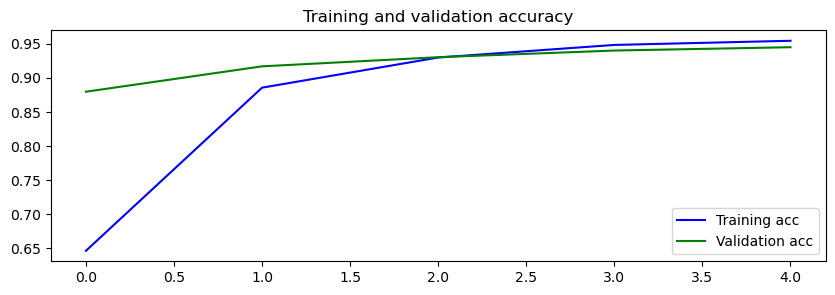

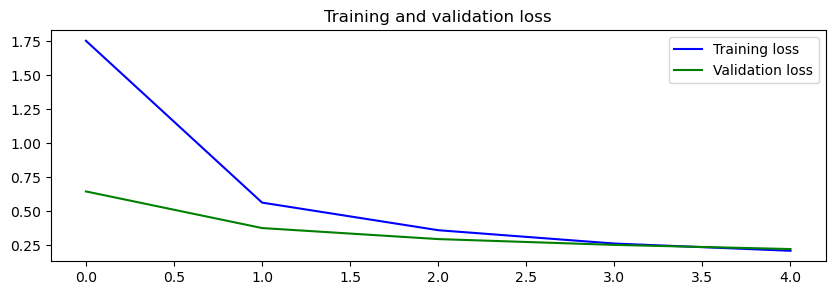

In [63]:
plot_history(history.history)

In [64]:
model.save('./working/model_step1.keras')
model.load_weights('best_model.keras')

In [66]:
scores = model.evaluate(test_generator, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))

205/205 ━━━━━━━━━━━━━━━━━━━━ 59s 288ms/step - accuracy: 0.9451 - loss: 0.2223
Accuracy: 94.51%


## Step 2

In [67]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  238


In [68]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers)//2

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable =  False

In [69]:
len(base_model.trainable_variables)

107

In [70]:
# Check the trainable status of the individual layers
for layer in model.layers:
    print(layer, layer.trainable)

<Functional name=efficientnetb0, built=True> True
<GlobalAveragePooling2D name=global_average_pooling2d_1, built=True> True
<Dense name=dense_1, built=True> True


In [71]:
LR=0.0001
model.compile(loss="categorical_crossentropy", optimizer=optimizers.Adam(learning_rate=LR), metrics=["accuracy"])

In [72]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,180,233 (15.95 MB)

 Trainable params: 3,829,550 (14.61 MB)

 Non-trainable params: 350,683 (1.34 MB)

In [73]:
scores = model.evaluate(test_generator, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))

205/205 ━━━━━━━━━━━━━━━━━━━━ 62s 294ms/step - accuracy: 0.9451 - loss: 0.2223
Accuracy: 94.51%


In [74]:
# Обучаем
history = model.fit(
    train_generator,
    validation_data = test_generator,
    epochs = EPOCHS,
    callbacks = callbacks_list,
    verbose=1,    
)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.8364 - loss: 0.7367
Epoch 1: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 530s 635ms/step - accuracy: 0.8959 - loss: 0.4748 - val_accuracy: 0.9615 - val_loss: 0.1420
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9577 - loss: 0.1947
Epoch 2: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 515s 629ms/step - accuracy: 0.9589 - loss: 0.1827 - val_accuracy: 0.9713 - val_loss: 0.1204
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.9706 - loss: 0.1298
Epoch 3: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 511s 624ms/step - accuracy: 0.9715 - loss: 0.1253 - val_accuracy: 0.9750 - val_loss: 0.0968
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.9837 - loss: 0.0813
Epoch 4: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 494s 603ms/step - accuracy: 0.9802 - loss: 0.0841 - val_accuracy: 0.9768 - val_loss: 0.0909


In [75]:
model.save('./working/model_step2.keras')
model.load_weights('best_model.keras')

In [76]:
scores = model.evaluate(test_generator, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))

205/205 ━━━━━━━━━━━━━━━━━━━━ 53s 260ms/step - accuracy: 0.9811 - loss: 0.0815
Accuracy: 98.11%


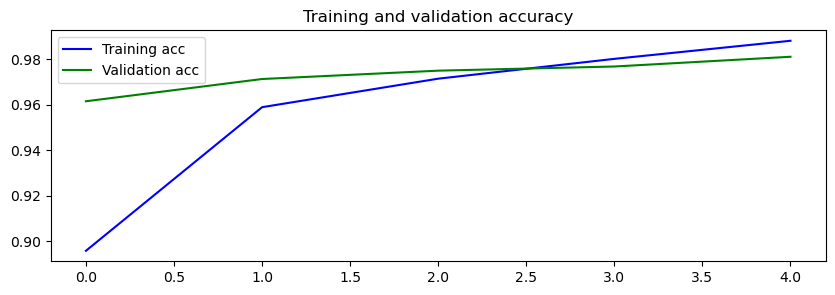

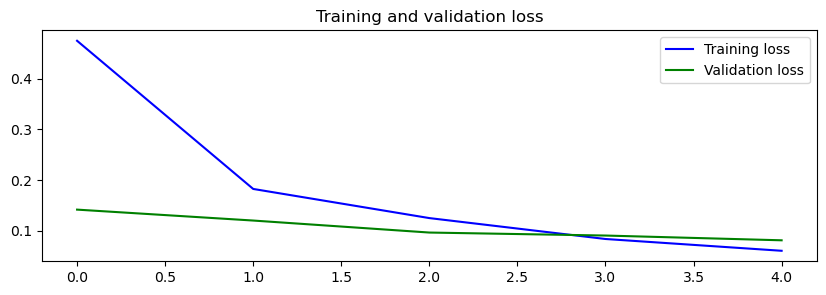

In [77]:
plot_history(history.history)

## Step 3

In [78]:
model.load_weights('best_model.keras')

In [79]:
base_model.trainable = True

In [80]:
LR=0.00001
model.compile(loss="categorical_crossentropy", optimizer=optimizers.Adam(learning_rate=LR), metrics=["accuracy"])

In [81]:
# Обучаем
history = model.fit(
    train_generator,
    validation_data = test_generator,
    epochs = EPOCHS,
    callbacks = callbacks_list,
    verbose=1,
)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9870 - loss: 0.0559
Epoch 1: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 506s 605ms/step - accuracy: 0.9893 - loss: 0.0519 - val_accuracy: 0.9860 - val_loss: 0.0720
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9917 - loss: 0.0435
Epoch 2: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 493s 601ms/step - accuracy: 0.9908 - loss: 0.0448 - val_accuracy: 0.9866 - val_loss: 0.0670
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9916 - loss: 0.0426
Epoch 3: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 1105s 1s/step - accuracy: 0.9924 - loss: 0.0400 - val_accuracy: 0.9853 - val_loss: 0.0648
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9925 - loss: 0.0357
Epoch 4: saving model to best_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 521s 636ms/step - accuracy: 0.9924 - loss: 0.0362 - val_accuracy: 0.9860 - val_loss: 0.0610
Epoch

In [82]:
model.save('./working/model_step3.keras')
model.load_weights('best_model.keras')

In [83]:
scores = model.evaluate(test_generator, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))

205/205 ━━━━━━━━━━━━━━━━━━━━ 53s 257ms/step - accuracy: 0.9866 - loss: 0.0614
Accuracy: 98.66%


# Step 4

In [94]:
EPOCHS               = 2
BATCH_SIZE           = 8 # уменьшаем batch если сеть большая, иначе не влезет в память на GPU
LR                   = 1e-4

IMG_SIZE             = 512
IMG_CHANNELS         = 3
input_shape          = (IMG_SIZE, IMG_SIZE, IMG_CHANNELS)

In [95]:
train_datagen = ImageDataGenerator(
    #rotation_range = 90,
    #shear_range=0.2,
    zoom_range=[0.75,1.25],
    #brightness_range=[0.5, 1.5],
    #width_shift_range=0.1,
    #height_shift_range=0.1,
    horizontal_flip=True,
)
test_datagen = ImageDataGenerator()

In [96]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_files,
    directory=PATH,
    x_col="Id",
    y_col="Category",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=RANDOM_SEED,)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_files,
    directory=PATH,
    x_col="Id",
    y_col="Category",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=RANDOM_SEED,)

Found 6551 validated image filenames belonging to 102 classes.
Found 1638 validated image filenames belonging to 102 classes.


In [97]:
# Прямой импорт из актуального Keras
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet', 
    include_top=False, 
    input_shape=input_shape
)

In [98]:
model=M.Sequential()
model.add(base_model)
model.add(L.GlobalAveragePooling2D(),)
model.add(L.Dense(CLASS_NUM, activation='softmax'))

In [99]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 16, 16, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,180,233 (15.95 MB)

 Trainable params: 4,138,210 (15.79 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [100]:
model.compile(
    loss="categorical_crossentropy", 
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR), 
    metrics=["accuracy"]
)


In [101]:
model.load_weights('best_model.keras')

/home/itj/anaconda3/envs/dl/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 220 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [102]:
# Обучаем
history = model.fit(
    train_generator,
    validation_data = test_generator,
    epochs = EPOCHS,
    callbacks = callbacks_list,
    verbose=1,
)

Epoch 1/2
 76/819 ━━━━━━━━━━━━━━━━━━━━ 1:18:25 6s/step - accuracy: 0.9181 - loss: 0.3859

KeyboardInterrupt: 

In [103]:
model.save('./working/model_step4.keras')
model.load_weights('best_model.keras')

/home/itj/anaconda3/envs/dl/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 428 variables whereas the saved optimizer has 220 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [104]:
scores = model.evaluate(test_generator, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))

205/205 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.9646 - loss: 0.1475
Accuracy: 96.46%


# Final Score

In [105]:
from sklearn.metrics import accuracy_score

In [106]:
# Используем чистый метод predict, принудительно отключив внутренние генераторы-обертки
predictions_raw = model.predict(test_generator, verbose=1)
predictions = np.argmax(predictions_raw, axis=-1)

label_map = (train_generator.class_indices)
label_map = dict((v, k) for k, v in label_map.items())
predictions = [int(label_map[k]) for k in predictions] # Приводим к int, чтобы типы точно совпали с датафреймом


205/205 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step


In [107]:
filenames_with_dir=test_generator.filenames
submission = pd.DataFrame({'Predict':predictions}, columns=['Predict'], index=filenames_with_dir)
test_files.index = test_files['Id']
tmp_y = pd.concat([submission['Predict'], test_files['Category']], axis=1, sort=False)
tmp_y.head(5)

,Predict,Category
jpg/image_05001.jpg,46,46
jpg/image_07204.jpg,6,6
jpg/image_04014.jpg,11,11
jpg/image_07420.jpg,93,93
jpg/image_01122.jpg,45,45


In [108]:
filenames_with_dir = test_generator.filenames
submission = pd.DataFrame({'Predict': predictions}, index=filenames_with_dir)

# Создаем чистую таблицу для сравнения, сбрасывая индексы
tmp_y = pd.DataFrame({
    'Predict': predictions,
    'Category': test_files['Category'].values # Берем чистые значения (массив), игнорируя индексы
})
print(tmp_y.head(5))


   Predict Category
0       46       46
1        6        6
2       11       11
3       93       93
4       45       45


In [109]:
print('Accuracy: %.2f%%' % (accuracy_score(tmp_y['Category'], tmp_y['Predict'],)*100))

Accuracy: 0.00%


In [119]:
# Приводим оба столбца к типу int перед сравнением
true_labels = tmp_y['Category'].astype(int)
predicted_labels = tmp_y['Predict'].astype(int)

print('Реальная Accuracy: %.2f%%' % (accuracy_score(true_labels, predicted_labels) * 100))


Реальная Accuracy: 95.85%


# TTA

In [110]:
model.load_weights('best_model.keras')

/home/itj/anaconda3/envs/dl/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 428 variables whereas the saved optimizer has 220 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [111]:
# Убрали rescale, оставив только искажения для TTA
test_datagen = ImageDataGenerator(
    rotation_range=90,
    shear_range=0.2,
    zoom_range=[0.75, 1.25],
    brightness_range=[0.5, 1.5],
    width_shift_range=0.1,
    height_shift_range=0.1
)


In [112]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_files,
    directory=PATH,
    x_col="Id",
    y_col="Category",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=RANDOM_SEED,)

Found 1638 validated image filenames belonging to 102 classes.


Пример картинок из test_generator


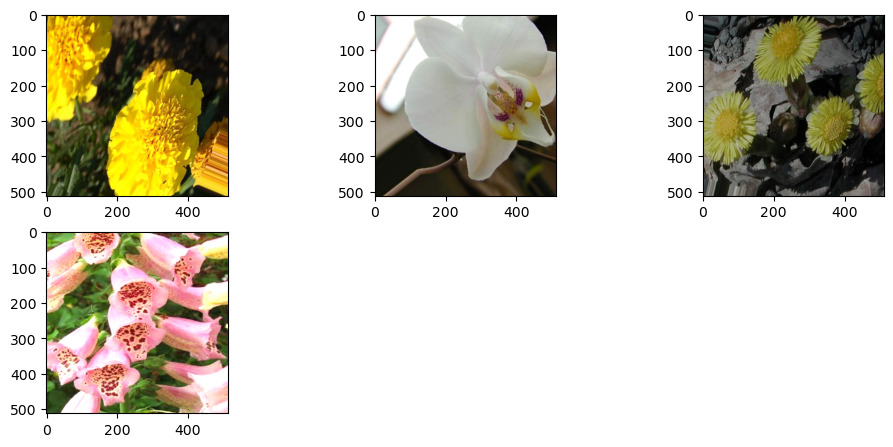

In [114]:
x, y = next(test_generator)
print('Пример картинок из test_generator')
plt.figure(figsize=(12, 8))

for i in range(0, 4):
    image = x[i]
    plt.subplot(3, 3, i + 1)
    # Приводим к uint8, чтобы картинки не белели без rescale
    plt.imshow(image.astype('uint8')) 
    
plt.show()


In [115]:
tta_steps = 10
predictions = []

In [116]:
for i in range(tta_steps):
    test_generator.reset() # Сбрасываем итератор, чтобы гарантировать правильный порядок файлов
    preds = model.predict(test_generator, verbose=1)
    predictions.append(preds)
    
pred = np.mean(predictions, axis=0)


205/205 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step


In [117]:
predictions = np.argmax(pred, axis=-1)
label_map = (train_generator.class_indices)
label_map = dict((v, k) for k, v in label_map.items())
predictions = [int(label_map[k]) for k in predictions] # Приводим к int для совпадения типов

filenames_with_dir = test_generator.filenames
submission = pd.DataFrame({'Predict': predictions}, index=filenames_with_dir)

# Надежная сборка проверочной таблицы без привязки к индексам строк
tmp_y = pd.DataFrame({
    'Predict': predictions,
    'Category': test_files['Category'].values
})


In [122]:
tmp_y

,Predict,Category
0,46,46
1,6,6
2,11,11
3,93,93
4,45,45
...,...,...
1633,81,81
1634,86,86
1635,88,88
1636,15,15


In [120]:
print('Accuracy: %.2f%%' % (accuracy_score(tmp_y['Category'], tmp_y['Predict'],)*100))

Accuracy: 0.00%


In [121]:
# Приводим оба столбца к типу int перед сравнением
true_labels = tmp_y['Category'].astype(int)
predicted_labels = tmp_y['Predict'].astype(int)

print('Реальная Accuracy: %.2f%%' % (accuracy_score(true_labels, predicted_labels) * 100))


Реальная Accuracy: 95.85%


## clean